This notebook contains code for generating images related to quantum neural networks used in the article regarding Umlaut data.

<a id="0"></a>
1. [Visualizing a Strongly Entangling Layer in PennyLane](#1)
2. [Umlaut dataset Current and Power](#2)
3. [Umlaut loss function](#3)

<a id="1"></a> <br>
### Visualizing a Strongly Entangling Layer in PennyLane

This quantum circuit is designed to visualize the **StronglyEntanglingLayers** feature in PennyLane. It consists of 4 qubits and applies a strongly entangling layer with randomly initialized parameters. The circuit is drawn using `qml.draw_mpl()`, allowing for graphical visualization of the quantum operations at the device level.

- **Device**: `default.qubit` (simulated quantum device with 4 qubits)
- **Layer**: `qml.StronglyEntanglingLayers` (entangling quantum gate layer)
- **Visualization**: Uses Matplotlib to render the circuit structure

This visualization helps in understanding how strongly entangling layers are structured and how they affect quantum states in a variational quantum algorithm.


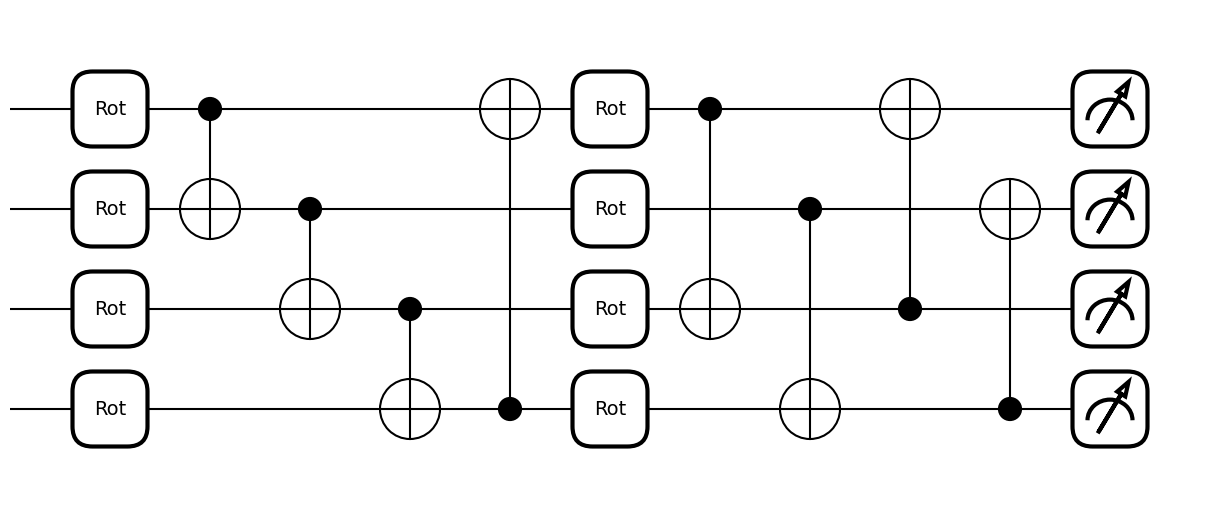

In [14]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# efine your original circuit:
dev = qml.device('default.qubit', wires=4)

@qml.qnode(dev)
def circuit(parameters):
    qml.StronglyEntanglingLayers(weights=parameters, wires=range(4))
    return qml.state()

shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=4)
weights = np.random.random(size=shape)

# Draw the transformed tape:
fig, ax = qml.draw_mpl(circuit, show_all_wires=True, show_wire_labels=False, level="device")(weights)
plt.show()


<a id="2"></a> <br>
### Umlaut dataset Current and Power

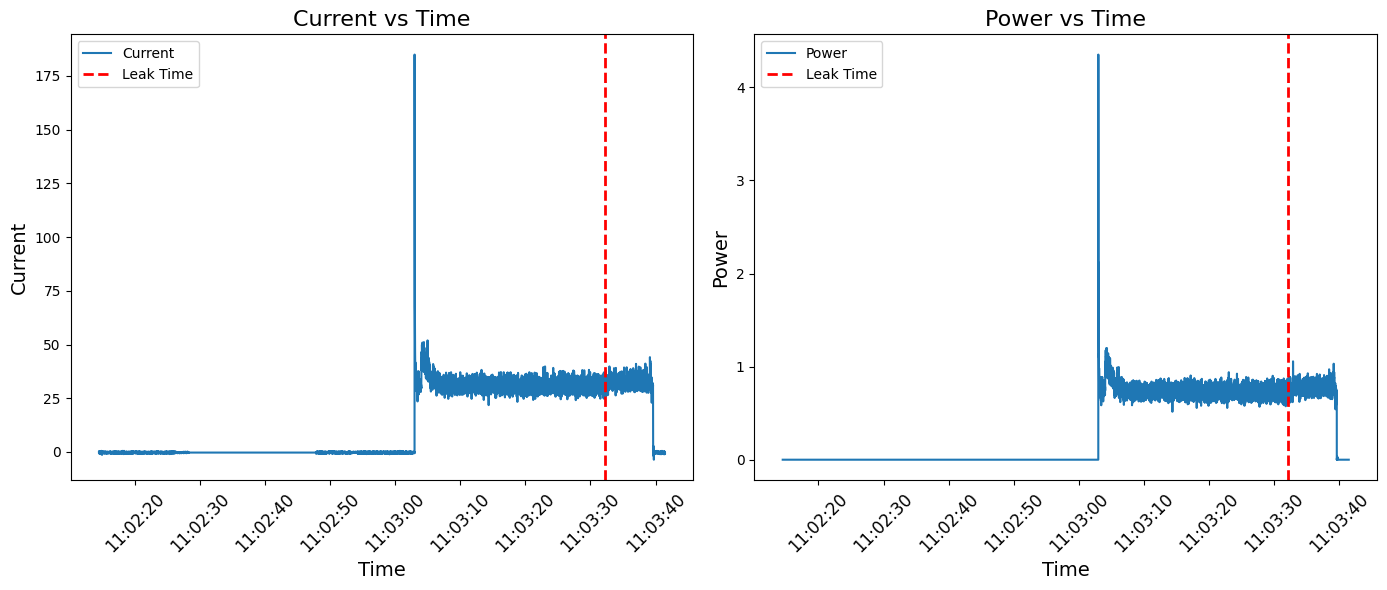

In [1]:
from Utils import clean_data, plot_current_and_power
from Utils import load_csv_files

folder_path = "../data_fabrik/cleaned"
runs_metadata, runs_files = load_csv_files(folder_path)
runs_metadata, runs_files = clean_data(runs_metadata, runs_files)
plot_current_and_power(4046, runs_files)

<a id="3"></a> <br>
## Umlaut loss function

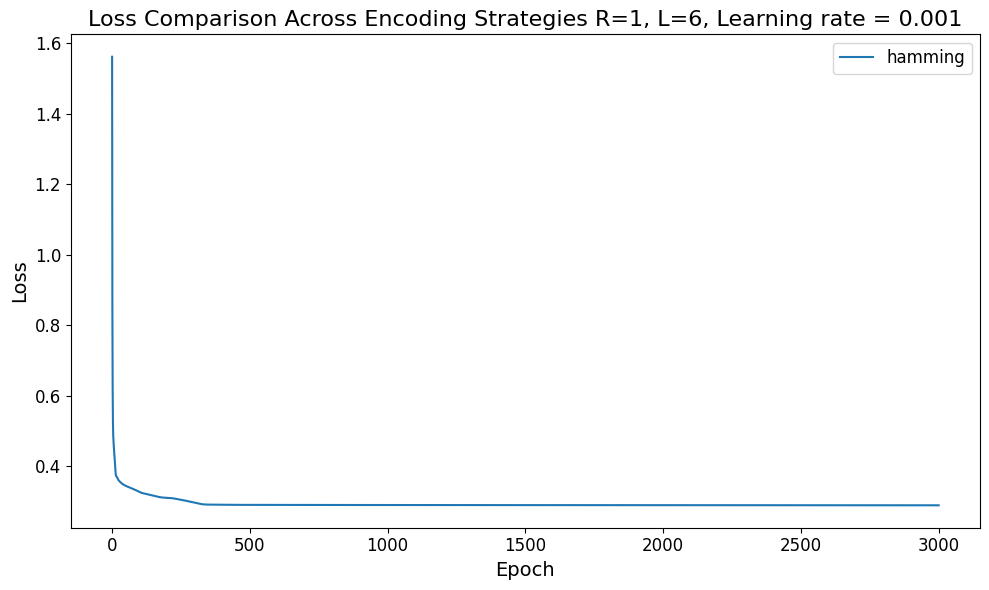

In [6]:
from Utils import load_qnn_output
import json
import matplotlib.pyplot as plt
import numpy as np

data = load_qnn_output('hamming_1_6_001.json')

losses_by_encoding = {}

for experiment in data:
    config = experiment['Model_Configuration']
    encoding = config['Encoding']
    loss_values = config['Loss_Values']
    learning_rate = config['Step_Size']

    if encoding not in losses_by_encoding:
        losses_by_encoding[encoding] = []
    losses_by_encoding[encoding].append(loss_values)

plt.figure(figsize=(10, 6))
for encoding, loss_lists in losses_by_encoding.items():
    loss_array = np.array(loss_lists)
    mean_loss_curve = np.mean(loss_array, axis=0)
    plt.plot(mean_loss_curve, label=encoding)

# Increase font sizes for labels, title, legend, and ticks
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title(f'Loss Comparison Across Encoding Strategies R=1, L=6, Learning rate = {learning_rate}', fontsize=16)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig(f"Loss_Comparison_Encodings_{learning_rate}.png")
plt.show()


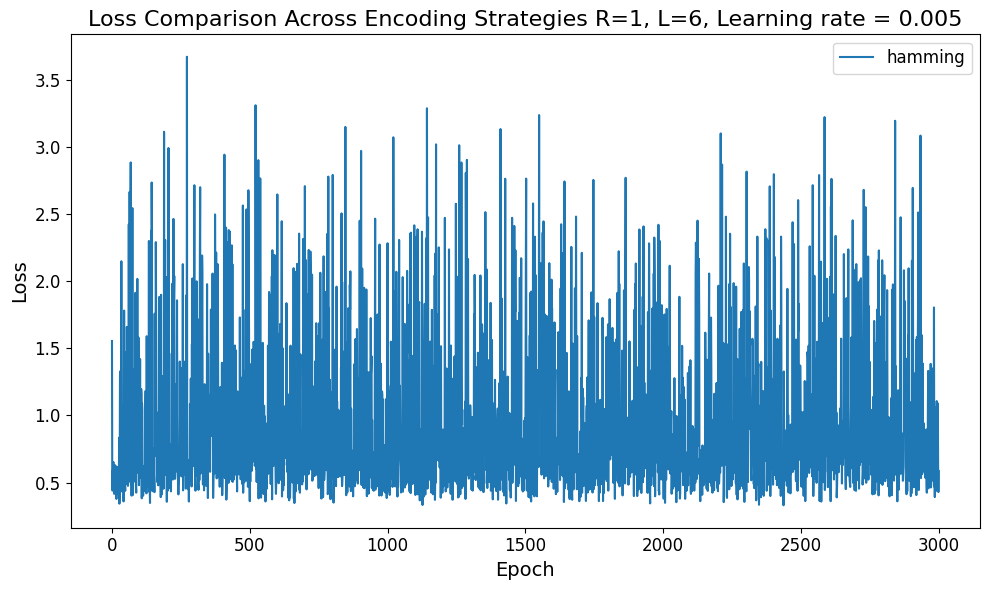

In [9]:
from Utils import load_qnn_output
import json
import matplotlib.pyplot as plt
import numpy as np

data = load_qnn_output('hamming_1_6_005.json')

losses_by_encoding = {}

for experiment in data:
    config = experiment['Model_Configuration']
    encoding = config['Encoding']
    loss_values = config['Loss_Values']
    learning_rate = config['Step_Size']

    if encoding not in losses_by_encoding:
        losses_by_encoding[encoding] = []
    losses_by_encoding[encoding].append(loss_values)

plt.figure(figsize=(10, 6))
for encoding, loss_lists in losses_by_encoding.items():
    loss_array = np.array(loss_lists)
    mean_loss_curve = np.mean(loss_array, axis=0)
    plt.plot(mean_loss_curve, label=encoding)

# Increase font sizes for labels, title, legend, and ticks
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title(f'Loss Comparison Across Encoding Strategies R=1, L=6, Learning rate = {learning_rate}', fontsize=16)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig(f"Loss_Comparison_Encodings_{learning_rate}.png")
plt.show()

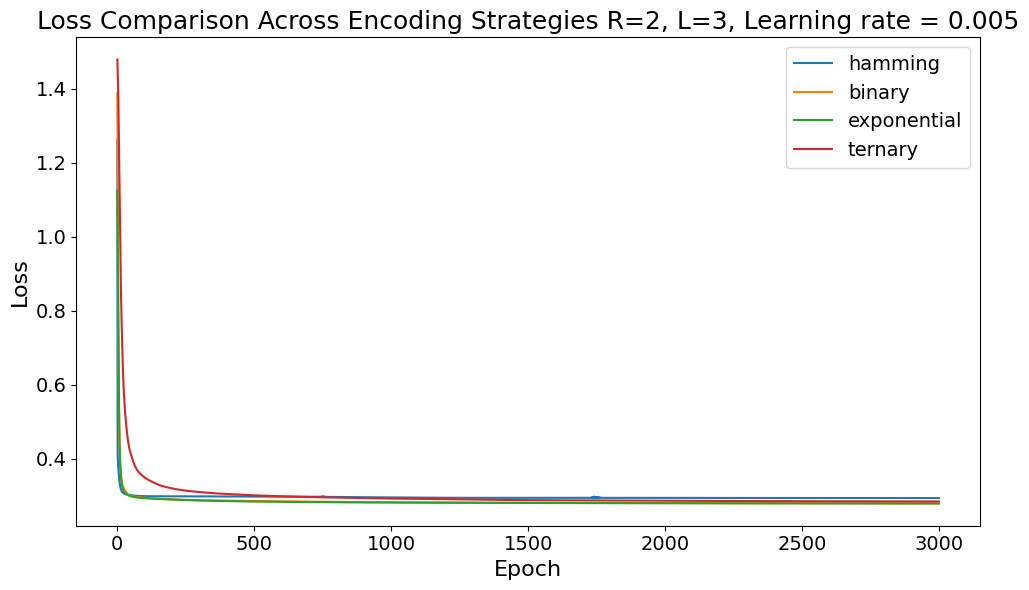

In [7]:
from Utils import load_qnn_output
import json
import matplotlib.pyplot as plt
import numpy as np


data = load_qnn_output('Test_to_Plot_2_3.json')

losses_by_encoding = {}

for experiment in data:
    config = experiment['Model_Configuration']
    encoding = config['Encoding']
    loss_values = config['Loss_Values']
    learning_rate = config['Step_Size']

    if encoding not in losses_by_encoding:
        losses_by_encoding[encoding] = []
    losses_by_encoding[encoding].append(loss_values)

plt.figure(figsize=(10, 6))
for encoding, loss_lists in losses_by_encoding.items():

    loss_array = np.array(loss_lists)
    mean_loss_curve = np.mean(loss_array, axis=0)
    plt.plot(mean_loss_curve, label=encoding)
# Increase font sizes for labels, title, legend, and ticks
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title(f'Loss Comparison Across Encoding Strategies R=2, L=3, Learning rate = {learning_rate}', fontsize=18)
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

#plt.grid(True)
plt.tight_layout()
plt.savefig("Loss_Comparison_Encodings_2_3.png")
plt.show()

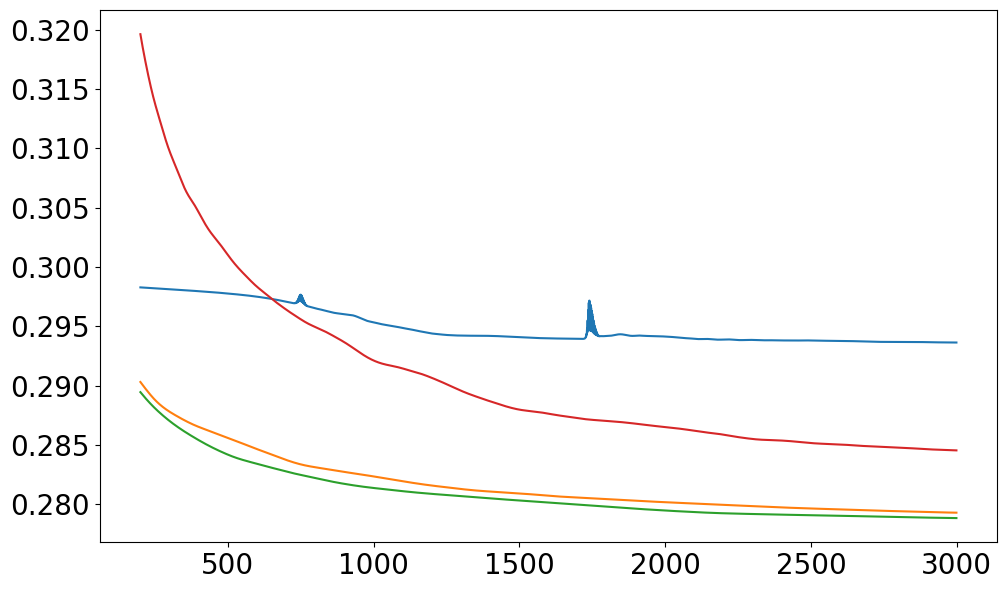

In [11]:

from Utils import load_qnn_output
import json
import matplotlib.pyplot as plt
import numpy as np

data = load_qnn_output('Test_to_Plot_2_3.json')

losses_by_encoding = {}

for experiment in data:
    config = experiment['Model_Configuration']
    encoding = config['Encoding']
    loss_values = config['Loss_Values']

    if encoding not in losses_by_encoding:
        losses_by_encoding[encoding] = []
    losses_by_encoding[encoding].append(loss_values)

plt.figure(figsize=(10, 6))
for encoding, loss_lists in losses_by_encoding.items():
    loss_array = np.array(loss_lists)
    mean_loss_curve = np.mean(loss_array, axis=0)
    # Slice the data from epoch 200 to 300 and create corresponding x-axis values
    epochs = np.arange(200, 3000)
    plt.plot(epochs, mean_loss_curve[200:3000], label=encoding)

plt.xlabel("",fontsize=20)
plt.ylabel("",fontsize=20)
#plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
#plt.legend()
plt.tight_layout()
plt.savefig("Loss_Comparison_Encodings_2_3_200_3000.png")
plt.show()


In [2]:
import numpy as np
from itertools import product

# Parameters
L = 3  # Number of layers
R = 2  # Number of qubits (not directly used here, but included for context)

# Eigenvalues of the Pauli-Z/2 subgenerator
eigenvalues = np.array([0.5, -0.5])  # Scaled by 1/2

# Compute all possible differences per layer
differences = []
for i in range(len(eigenvalues)):
    for j in range(len(eigenvalues)):
        diff = eigenvalues[i] - eigenvalues[j]
        differences.append(diff)

differences = np.unique(differences)  # {-1, 0, 1}
print(f"Differences per layer: {differences}")

# Generate all possible combinations of differences across L layers
all_combinations = list(product(differences, repeat=L))
print(f"Total number of combinations: {len(all_combinations)}")

# Calculate the sum of differences for each combination
frequencies = [sum(combo) for combo in all_combinations]

# Count the degeneracy for each unique frequency
unique_frequencies = np.unique(frequencies)
degeneracy = {}
for omega in unique_frequencies:
    degeneracy[omega] = frequencies.count(omega)

# Print results
print("\nDegeneracy deg(omega) for each frequency:")
for omega in sorted(degeneracy.keys()):
    print(f"deg({int(omega)}) = {degeneracy[omega]}")

# Verify total combinations
total_degeneracy = sum(degeneracy.values())
print(f"\nTotal degeneracy sum: {total_degeneracy} (should equal 3^6 = 729)")

Differences per layer: [-1.  0.  1.]
Total number of combinations: 27

Degeneracy deg(omega) for each frequency:
deg(-3) = 1
deg(-2) = 3
deg(-1) = 6
deg(0) = 7
deg(1) = 6
deg(2) = 3
deg(3) = 1

Total degeneracy sum: 27 (should equal 3^6 = 729)
